In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch

In [2]:
q = np.geomspace(0.1, 1, 3000)
R = 5
F_sphere = 3*(np.sin(q*R) - q*R*np.cos(q*R))/(q*R)**3

In [3]:
I_monomer = F_sphere**2
x = 2*R
I_dimer = F_sphere**2*(2 + 2*np.sin(q*x)/(q*x))
x = 2*R
I_triplet = F_sphere**2*(3 + 6*np.sin(q*x)/(q*x))
x = 2*R
I_tetrahedral = F_sphere**2*(4 + 12*np.sin(q*x)/(q*x))
x = 2*R
I_dipyramid = F_sphere**2*(5 + 18*np.sin(q*x)/(q*x) + 2*(np.sin(np.sqrt(8/3)*q*x)/(np.sqrt(8/3)*q*x)))

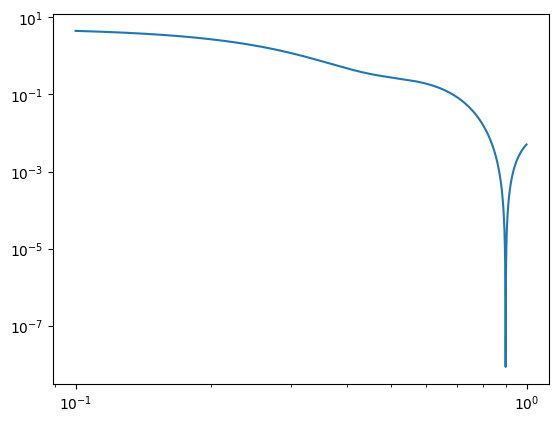

In [18]:
p_monomer = 0.25
p_dimer = 0.20
p_triplet = 0.15
p_tetrahedral = 0.10
p_dipyramid = 0.05
Iq_total = I_monomer*p_monomer + I_dimer*p_dimer + I_triplet*p_triplet + I_tetrahedral*p_tetrahedral + I_dipyramid*p_dipyramid

plt.loglog(q, Iq_total)
data = np.hstack((q.reshape(-1,1), Iq_total.reshape(-1,1)))

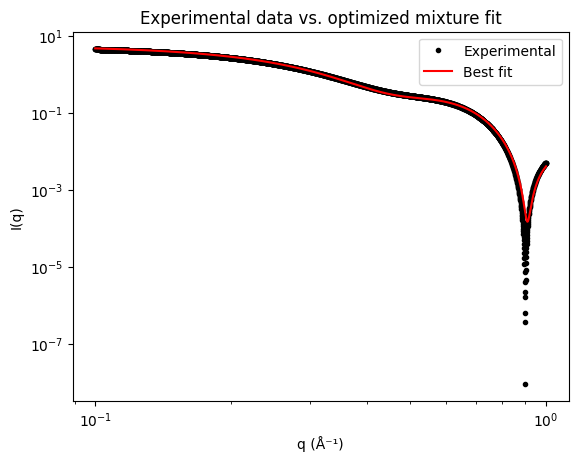

In [19]:
# Imports required for the MC-DFM workflow
import sys
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------------------
def random_points_in_sphere(radius, n_points):
    """Generate uniformly distributed points inside a sphere of given radius."""
    u = np.random.uniform(0, 1, n_points)
    costheta = np.random.uniform(-1, 1, n_points)
    phi = np.random.uniform(0, 2*np.pi, n_points)
    r = radius * np.cbrt(u)          # inverse transform for uniform volume
    sin_theta = np.sqrt(1 - costheta**2)
    x = r * sin_theta * np.cos(phi)
    y = r * sin_theta * np.sin(phi)
    z = r * costheta
    sld = np.ones((n_points, 1))     # uniform SLD difference
    return np.column_stack((x, y, z, sld))

def build_assembly(sphere_template, centers):
    """Translate a template sphere to several centers and stack the coordinates."""
    all_coords = [sphere_template + np.array([cx, cy, cz, 0]) for cx, cy, cz in centers]
    return np.vstack(all_coords)

# ------------------------------------------------------------------------
# Parameters for the 10 nm spheres
# ------------------------------------------------------------------------
radius_A = 5.0                     # Angstrom (10 nm = 100 Å diameter)
n_points_per_sphere = 2000           # number of points inside each sphere
sphere_template = random_points_in_sphere(radius_A, n_points_per_sphere)

# ------------------------------------------------------------------------
# Define the centres of each assembly
# ------------------------------------------------------------------------
gap = 10.0         # centre‑centre separation to avoid overlap ( > 2*radius )

# 1. Monomer
centers_monomer = np.array([[0, 0, 0]])

# 2. Dimer (two spheres in a line)
centers_dimer = np.array([[0, 0, 0],
                          [gap, 0, 0]])

# 3. Triangular triplet
centers_triplet = np.array([[0, 0, 0],
                            [gap, 0, 0],
                            [gap/2, gap*np.sqrt(3)/2, 0]])

# 4. Tetrahedral (3 in triangle + one above triangle centre, h = 80 Å)
centroid = np.mean(centers_triplet, axis=0)
h_center = 8.0                      # sufficient to keep centre sphere non‑overlapping
centers_tetra = np.vstack((centers_triplet,
                           centroid + np.array([0, 0, h_center])))

# 5. Trigonal dipyramid (tetrahedral + one below triangle centre, h = -80 Å)
centers_pyramid = np.vstack((centers_triplet,
                             centroid + np.array([0, 0, -h_center])))
# ------------------------------------------------------------------------
# Build coordinate arrays for each assembly
# ------------------------------------------------------------------------
coords_monomer = build_assembly(sphere_template, centers_monomer)
coords_dimer   = build_assembly(sphere_template, centers_dimer)
coords_triplet = build_assembly(sphere_template, centers_triplet)
coords_tetra   = build_assembly(sphere_template, centers_tetra)
coords_pyramid = build_assembly(sphere_template, centers_pyramid)

# ------------------------------------------------------------------------
# Scattering simulation parameters
# ------------------------------------------------------------------------
n_pairwise = 10000000
histogram_bins = 10000
q = np.geomspace(0.1, 1.0, 3000)

# ------------------------------------------------------------------------
# Simulate scattering for each assembly
# ------------------------------------------------------------------------
Iq_mono  = fitting.simulate_scattering(coords_monomer, q, histogram_bins, n_pairwise, mode='single')
Iq_dim   = fitting.simulate_scattering(coords_dimer,   q, histogram_bins, n_pairwise, mode='single')
Iq_tri   = fitting.simulate_scattering(coords_triplet, q, histogram_bins, n_pairwise, mode='single')
Iq_tet   = fitting.simulate_scattering(coords_tetra,   q, histogram_bins, n_pairwise, mode='single')
Iq_pyr   = fitting.simulate_scattering(coords_pyramid, q, histogram_bins, n_pairwise, mode='single')

# ------------------------------------------------------------------------
# Invariants for each assembly
# ------------------------------------------------------------------------
Inv_mono = fitting.invariant(np.column_stack((q, Iq_mono)))
Inv_dim  = fitting.invariant(np.column_stack((q, Iq_dim)))
Inv_tri  = fitting.invariant(np.column_stack((q, Iq_tri)))
Inv_tet  = fitting.invariant(np.column_stack((q, Iq_tet)))
Inv_pyr  = fitting.invariant(np.column_stack((q, Iq_pyr)))

# ------------------------------------------------------------------------
# Number of spheres in each assembly (used for scaling)
# ------------------------------------------------------------------------
N_mono = 1
N_dim  = 2
N_tri  = 3
N_tet  = 4
N_pyr  = 5

# ------------------------------------------------------------------------
# Equal proportions for an initial mixture
# ------------------------------------------------------------------------
prop_mono = 0.2
prop_dim  = 0.2
prop_tri  = 0.2
prop_tet  = 0.2
prop_pyr  = 0.2

# ------------------------------------------------------------------------
# Scale each assembly intensity by its invariant, number of subunits, and proportion
# ------------------------------------------------------------------------
Iq_mono_s = fitting.scale_intensity(Iq_mono, Inv_mono, N_mono, prop_mono)
Iq_dim_s  = fitting.scale_intensity(Iq_dim,  Inv_dim,  N_dim,  prop_dim)
Iq_tri_s  = fitting.scale_intensity(Iq_tri,  Inv_tri,  N_tri,  prop_tri)
Iq_tet_s  = fitting.scale_intensity(Iq_tet,  Inv_tet,  N_tet,  prop_tet)
Iq_pyr_s  = fitting.scale_intensity(Iq_pyr,  Inv_pyr,  N_pyr,  prop_pyr)

# ------------------------------------------------------------------------
# Total mixture intensity
# ------------------------------------------------------------------------
Iq_total = Iq_mono_s + Iq_dim_s + Iq_tri_s + Iq_tet_s + Iq_pyr_s

# ------------------------------------------------------------------------
# Plot the simulated mixture
# ------------------------------------------------------------------------
# fitting.plot_intensity(q, Iq_total)
# plt.title('Simulated SAXS curve of equal‑proportion 10 nm sphere assemblies')
# plt.xlabel('q (Å⁻¹)')
# plt.ylabel('I(q)')
# plt.show()

# ------------------------------------------------------------------------
# Fitting algorithm to determine arbitrary proportions from experimental data
# ------------------------------------------------------------------------
def objective_function(parameters, param_config, exp_data=None, mode="single", plot=False):
    """
    Parameters dictionary is expected to contain:
    - prop_mono, prop_dim, prop_tri, prop_tet, prop_pyr
    - background: background level
    - scale: overall intensity scale
    """
    # ---- Scale parameters ----
    params = fitting.scale_parameters(parameters, param_config)

    # ---- Load experimental data ----
    # (Assumes exp_data is already a 2‑column array if provided)
    # For demonstration, exp_data can be passed directly to the function.

    # ---- Simulate each assembly using pre‑computed coordinates ----
    Iq_mono_s = fitting.scale_intensity(Iq_mono, Inv_mono, N_mono,
                                         params["prop_mono"])
    Iq_dim_s  = fitting.scale_intensity(Iq_dim,  Inv_dim,  N_dim,
                                         params["prop_dim"])
    Iq_tri_s  = fitting.scale_intensity(Iq_tri,  Inv_tri,  N_tri,
                                         params["prop_tri"])
    Iq_tet_s  = fitting.scale_intensity(Iq_tet,  Inv_tet,  N_tet,
                                         params["prop_tet"])
    Iq_pyr_s  = fitting.scale_intensity(Iq_pyr,  Inv_pyr,  N_pyr,
                                         params["prop_pyr"])

    # ---- Combine the mixture ----
    Iq_assembled = (Iq_mono_s + Iq_dim_s + Iq_tri_s + Iq_tet_s + Iq_pyr_s)

    # ---- Apply overall scale and background ----
    Iq_model = params["scale"] * Iq_assembled + params["background"]

    # ---- Wrap into a model array with matching q values ----
    model = np.column_stack((q, Iq_model))

    # ---- Convert to the same grid as exp_data if needed ----
    model = fitting.convert_data(exp_data, model)

    # ---- Compute a simple error metric (mean absolute log difference) ----
    error = np.mean(np.abs(np.log10(np.abs(exp_data[:, 1])) -
                          np.log10(np.abs(model[:, 1]))))

    # ---- Optional plotting ----

    return -error, model

# ------------------------------------------------------------------------
# Parameter configuration for the optimizer
# ------------------------------------------------------------------------
param_config = {
    "prop_mono": (0.0, 1),
    "prop_dim":  (0.0, 1),
    "prop_tri":  (0.0, 1),
    "prop_tet":  (0.0, 1),
    "prop_pyr":  (0.0, 1),
    "background": (1e-12, 1e-9),
    "scale": (1e-3, 1e0)
}

# ------------------------------------------------------------------------
# Example: Run the genetic‑algorithm optimizer on an experimental dataset
# ------------------------------------------------------------------------
# Load experimental data (user should provide actual file path)
exp_path = '../Data/experimental/example_data.txt'   # placeholder
exp_data = data    # assumes two columns: q, I(q)

# Run optimization
best_solution, _ = fitting.run_optimization(
    exp_data,
    param_config,
    batch_size=10,
    mutation_rate=0.15,
    iterations=30,      # increase for more thorough search
    objective_function=objective_function,
    mode="single"
)

# ------------------------------------------------------------------------
# Retrieve and plot the best fit
# ------------------------------------------------------------------------
best_params = fitting.scale_parameters(best_solution, param_config)
_, best_fit = objective_function(best_solution, param_config, exp_data, plot=True)

# Plot experimental and best fit together
plt.figure()
plt.loglog(exp_data[:, 0], exp_data[:, 1], 'k.', label='Experimental')
plt.loglog(best_fit[:, 0], best_fit[:, 1], 'r-', label='Best fit')
plt.xlabel('q (Å⁻¹)')
plt.ylabel('I(q)')
plt.legend()
plt.title('Experimental data vs. optimized mixture fit')
plt.show()

In [21]:
best_params

{'prop_mono': np.float64(0.779),
 'prop_dim': np.float64(0.601),
 'prop_tri': np.float64(0.161),
 'prop_tet': np.float64(0.341),
 'prop_pyr': np.float64(0.528),
 'background': np.float64(4.99501e-10),
 'scale': np.float64(0.007993)}

In [14]:
total = 0.1 + 0.2 + 0.3 + 0.4 + 0.5
print(0.1/1.5)
print(0.2/1.5)
print(0.3/1.5)
print(0.4/1.5)
print(0.5/1.5)

0.06666666666666667
0.13333333333333333
0.19999999999999998
0.26666666666666666
0.3333333333333333


In [22]:
total = best_params['prop_mono'] + best_params['prop_dim'] + best_params['prop_tri'] + best_params['prop_tet'] + best_params['prop_pyr']

In [23]:
print(best_params['prop_mono']/total)
print(best_params['prop_dim']/total)
print(best_params['prop_tri']/total)
print(best_params['prop_tet']/total)
print(best_params['prop_pyr']/total)

0.3232365145228216
0.24937759336099583
0.06680497925311203
0.14149377593360996
0.21908713692946058
